In [32]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import numpy as np 
import pandas as pd 
import tensorflow as tf 
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/samueltochora/rossman-featureengineered/Rossman_feature_engineered.csv


### Modelling 
This will involve training a hybrid deep learning model on our feature-engineered dataset to generate forecasts on the next 42 days on store sales. Later we will plot the forecasts, get metrics on how it performed and convert those prediction errors into monetary terms for business analysis.

To begin, we import our preprocessed dataset

In [33]:
df = pd.read_csv('/kaggle/input/datasets/samueltochora/rossman-featureengineered/Rossman_feature_engineered.csv')
df.head()

,Unnamed: 0,Day_sin,Day_cos,Month_sin,Store,Month_cos,Store_encoded,MonthsWithComp,Sales_log,StateHoliday,Open,DayOfWeek
0,1016098,0.781831,0.623490,0.5,4,0.866025,7824.550963,40.0,0.000000,1,0.0,2
1,1014983,0.974928,-0.222521,0.5,4,0.866025,7824.550963,40.0,9.204523,0,1.0,3
2,1013868,0.433884,-0.900969,0.5,4,0.866025,7824.550963,40.0,9.017726,0,1.0,4
3,1012753,-0.433884,-0.900969,0.5,4,0.866025,7824.550963,40.0,9.022926,0,1.0,5
4,1011638,-0.974928,-0.222521,0.5,4,0.866025,7824.550963,40.0,9.243678,0,1.0,6


#### checking null values

In [34]:
df.isnull().sum()

Unnamed: 0        0
Day_sin           0
Day_cos           0
Month_sin         0
Store             0
Month_cos         0
Store_encoded     0
MonthsWithComp    0
Sales_log         0
StateHoliday      0
Open              0
DayOfWeek         0
dtype: int64

### splitting dataset
 We will split this dataset into 3 sequential subsets i.e training set with 70% of the whole dataset tgat will be used for training the model and fitting the scaler i.e minmax scaler, validation set with 20% that will be used for hyperparameter tuning and the rest for testing set that will be used for model evaluation

In [35]:
n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7): int(n*0.9)]
test_df = df[int(n*0.9):]

#### Checking the shape of the resultant sets

In [36]:
print(test_df.shape)
print(val_df.shape)
print(train_df.shape)

(18307, 12)
(36612, 12)
(128144, 12)


The training set takes 128,144 entries, validation set 36,612 and test set 18, 307

### Scaling data
To avoid features with high values not to dominate features with low values, I will use MinMAX scaler that will standardize features uniformly between 0 and 1 without transforming or assuming our features follows a normal ditrisbution. Toa avoid data leakage, i will the scaler only on training data. The learned tranformations from fitting on training data will be applied to all subsets i.e training set, validation set and test set

In [37]:

scaler = MinMaxScaler()
scaler.fit(train_df)
train_df[train_df.columns] = scaler.transform(train_df[train_df.columns])
val_df[val_df.columns] =scaler.transform(val_df[val_df.columns])
test_df[test_df.columns] = scaler.transform(test_df[test_df.columns])

/tmp/ipykernel_58/940138150.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df[train_df.columns] = scaler.transform(train_df[train_df.columns])
/tmp/ipykernel_58/940138150.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  val_df[val_df.columns] =scaler.transform(val_df[val_df.columns])
/tmp/ipykernel_58/940138150.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

#### Data Windowing
This is a process of taking a sequence of data points and defining them into inputs and labels and fit them on a deep leearning model that will train on inputs and make predictions that will be evaluated by using labels. 

our data window class will first use `__init__` function to initialize sequential windows of inputs, labels and shift which is the number of timesteps separating the input sequence to labels i.e if we are predicting the next hour, shift = 1, if 24 hours shift will be 24 hours. this function will have our subsets and setting label column none for reusage of this class. Then derive the indices of features from the training set and labels.


The `split_window` function will extract the first portion of the time sequence to make inputs and end of time sequence to make labels and if the label column is not null, we will stack labels based on the index of the last column i.e is Sales log. Lastly it explicitly  sets the shape of the inputs to `batchsize, input_width, features` and labels  into `batchsize, label_width, target_features`

The `make_dataset` class will check the existence of the dataframe and Store column before grouping the time series windows for each store to avoid their overlap. If the length of the store subgroup is less than total_window_ size in our case 72 timesteps, it skips that store. Then extracting sequences of windows for each store and then indexing each store and drawing each batch from diffrent stores i.e 1st batch from store 0, 2nd batch from store 1 etc to avoid overfitting of the model due to drawing batches from one store continously. Lastly we split the total_window_size from each batch into inputs and labels. 

The `sample_batch` function extracts the cached single batch containing inputs and labels and if that batch  doesn't exist,it extracts and saves the first batch from the training pipeline for consistent plots and fast retrieval.




In [38]:


class RossmanWindowGenerator:
    def __init__(self, input_width, label_width, shift, train_df, val_df, test_df, label_columns=None):
        self.train_df = train_df 
        self.val_df = val_df 
        self.test_df = test_df 
        self.label_columns = label_columns 
        self.input_width = input_width 
        self.label_width = label_width 
        self.shift = shift 
        self.total_window_size = input_width + shift
        self.column_indices = {name: i for i, name in enumerate(train_df.columns)}
        
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in enumerate(label_columns)}
        
        self.input_slice = slice(0, input_width)
        self.label_slice = slice(self.total_window_size - label_width, None)

    def split_window(self, features):
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.label_slice, :]
        if self.label_columns is not None:
            labels = tf.stack([labels[:, :, self.column_indices[name]] for name in self.label_columns], axis=-1)
        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels 

    def make_dataset(self, data):
        if not isinstance(data, pd.DataFrame) or 'Store' not in data.columns:
            raise ValueError('Input data must be a dataframe with a "Store" column')
        
        datasets = []
        for store_id, group in data.groupby('Store'):
            if len(group) < self.total_window_size:
                continue
            
            ds = tf.keras.utils.timeseries_dataset_from_array(
                data=np.array(group, dtype=np.float32), 
                targets=None,
                sequence_length=self.total_window_size, 
                sequence_stride=1, 
                shuffle=True, 
                batch_size=32
            )
            datasets.append(ds)
        
        if not datasets:
            raise ValueError(f'No individual store had enough records matching the total window size ({self.total_window_size})')
        
        choice_dataset = tf.data.Dataset.range(len(datasets)).repeat()
        combine_ds = tf.data.Dataset.choose_from_datasets(datasets, choice_dataset)
        return combine_ds.map(self.split_window)

    @property 
    def train(self):
        return self.make_dataset(self.train_df)

    @property
    def val(self):
        return self.make_dataset(self.val_df)

    @property 
    def test(self):
        return self.make_dataset(self.test_df)

    @property
    def sample_batch(self):
        result = getattr(self, '_sample_batch', None)
        if result is None:
            result = next(iter(self.train))
            self._sample_batch = result 
        return result

    def plot(self, model=None, plot_col='Sales_log', max_subplots=3):
        inputs, labels = self.sample_batch
        plt.figure(figsize=(12, 8))
        plot_col_index = self.column_indices[plot_col]
        label_col_index = self.label_columns_indices.get(plot_col, None) if self.label_columns else None
        
        for n in range(min(max_subplots, len(inputs))):
            plt.subplot(max_subplots, 1, n + 1)
            plt.ylabel(f'{plot_col}')
            plt.plot(range(0, self.input_width), inputs[n, :, plot_col_index], label='Inputs', marker='.', zorder=-10)
            
            label_len = self.label_width
            if label_col_index is not None:
                plt.scatter(
                    range(self.total_window_size - label_len, self.total_window_size), 
                    labels[n, :, label_col_index], 
                    edgecolors='k', label='Labels', c='#2ca02c', s=64
                )
            
            if model is not None:
                predictions = model(inputs)
                if label_col_index is not None:
                    plt.scatter(
                        range(self.total_window_size - label_len, self.total_window_size), 
                        predictions[n, :, label_col_index],
                        marker='X', edgecolors='k', label='Predictions', c='#d62728', s=64
                    )
            if n == 0:
                plt.legend()
            plt.xlabel('Time Step')

        plt.tight_layout()
        plt.show()

    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {np.arange(self.input_width)}',
            f'Label indices: {np.arange(self.total_window_size - self.label_width, self.total_window_size)}'
        ])

In [39]:
rossman_window = RossmanWindowGenerator(input_width=30, label_width=42, shift=42, train_df=train_df, val_df=val_df, test_df=test_df, label_columns=['Sales_log'])

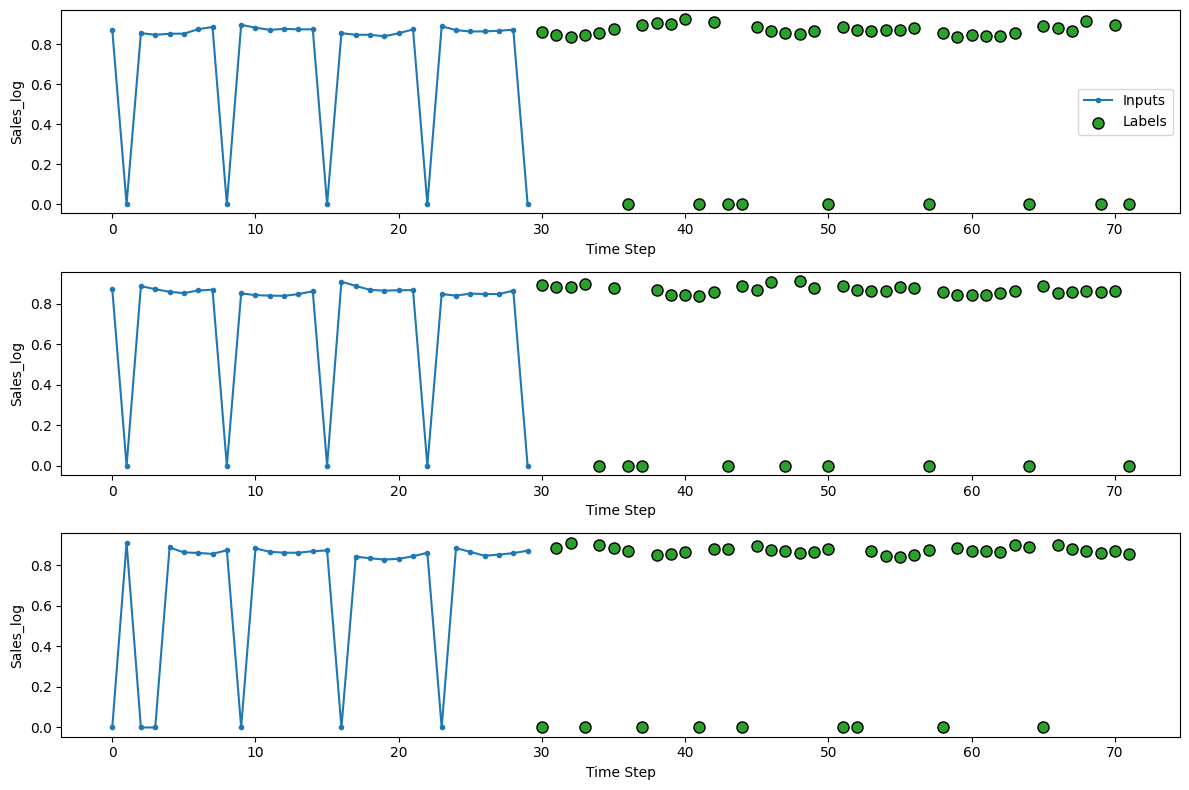

In [40]:
rossman_window.plot(plot_col='Sales_log')

In [41]:
for inputs, labels in rossman_window.train.take(1):
    sales_idx = rossman_window.column_indices['Sales_log']
    print()
    print('Minimum sales:', inputs[0, :, sales_idx].numpy().min())
    print('Max sales :', inputs[0, :, sales_idx].numpy().max())
    print()
    print("target value: ", labels[0, :, 0].numpy().min())
    print('target value: ', labels[0, :, 0].numpy().max())


Minimum sales: 0.0
Max sales : 0.9185185

target value:  0.0
target value:  0.9033648


In [42]:
num_features = train_df.shape[1]
num_labels = len(rossman_window.label_columns) if rossman_window.label_columns else num_features
current_input_width = rossman_window.input_width 
label_width = rossman_window.label_width 

past_inputs = tf.keras.Input(shape=(current_input_width, num_features), name='past_history')


x = tf.keras.layers.Conv1D(filters=64, kernel_size=7, padding='same', activation='relu')(past_inputs)
x = tf.keras.layers.BatchNormalization()(x)

x = tf.keras.layers.LSTM(128, return_sequences=True)(x)
x = tf.keras.layers.LSTM(64, return_sequences=False)(x)


x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.2)(x)


future_projection = tf.keras.layers.Dense(label_width * num_labels, activation='linear')(x)
final_outputs = tf.keras.layers.Reshape([label_width, num_labels])(future_projection)

structural_model = tf.keras.Model(inputs=past_inputs, outputs=final_outputs)


structural_model.compile(
    loss=tf.keras.losses.MeanSquaredError(), 
    optimizer=tf.keras.optimizers.AdamW(learning_rate=0.001, weight_decay=0.01), 
    metrics=[tf.keras.metrics.RootMeanSquaredError(), tf.keras.metrics.MeanAbsoluteError()]
)

structural_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ past_history (InputLayer)       │ (None, 30, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │         5,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 30, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 128)        │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 42)             │         5,418 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 42, 1)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,658 (654.91 KB)

 Trainable params: 167,530 (654.41 KB)

 Non-trainable params: 128 (512.00 B)

In [43]:
ossman_window = RossmanWindowGenerator(input_width=30, label_width=42, shift=42, train_df=train_df, val_df=val_df, test_df=test_df,label_columns=['Sales_log'])

In [44]:
lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

history = structural_model.fit(
    rossman_window.train.repeat(), epochs=35, steps_per_epoch=500, validation_data=rossman_window.val, validation_steps=150, 
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)]
)

Epoch 1/35
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - loss: 0.0653 - mean_absolute_error: 0.1729 - root_mean_squared_error: 0.2556 - val_loss: 0.0601 - val_mean_absolute_error: 0.2117 - val_root_mean_squared_error: 0.2451
Epoch 2/35
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0300 - mean_absolute_error: 0.1066 - root_mean_squared_error: 0.1731 - val_loss: 0.0342 - val_mean_absolute_error: 0.1306 - val_root_mean_squared_error: 0.1850
Epoch 3/35
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0275 - mean_absolute_error: 0.0998 - root_mean_squared_error: 0.1657 - val_loss: 0.0303 - val_mean_absolute_error: 0.1189 - val_root_mean_squared_error: 0.1740
Epoch 4/35
500/500 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - loss: 0.0258 - mean_absolute_error: 0.0951 - root_mean_squared_error: 0.1607 - val_loss: 0.0280 - val_mean_absolute_error: 0.1027 - val_root_mean_squared_error: 0.1672
Epoch 5/35
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.0244 - mean_absolute_error: 0.0919 - root_m

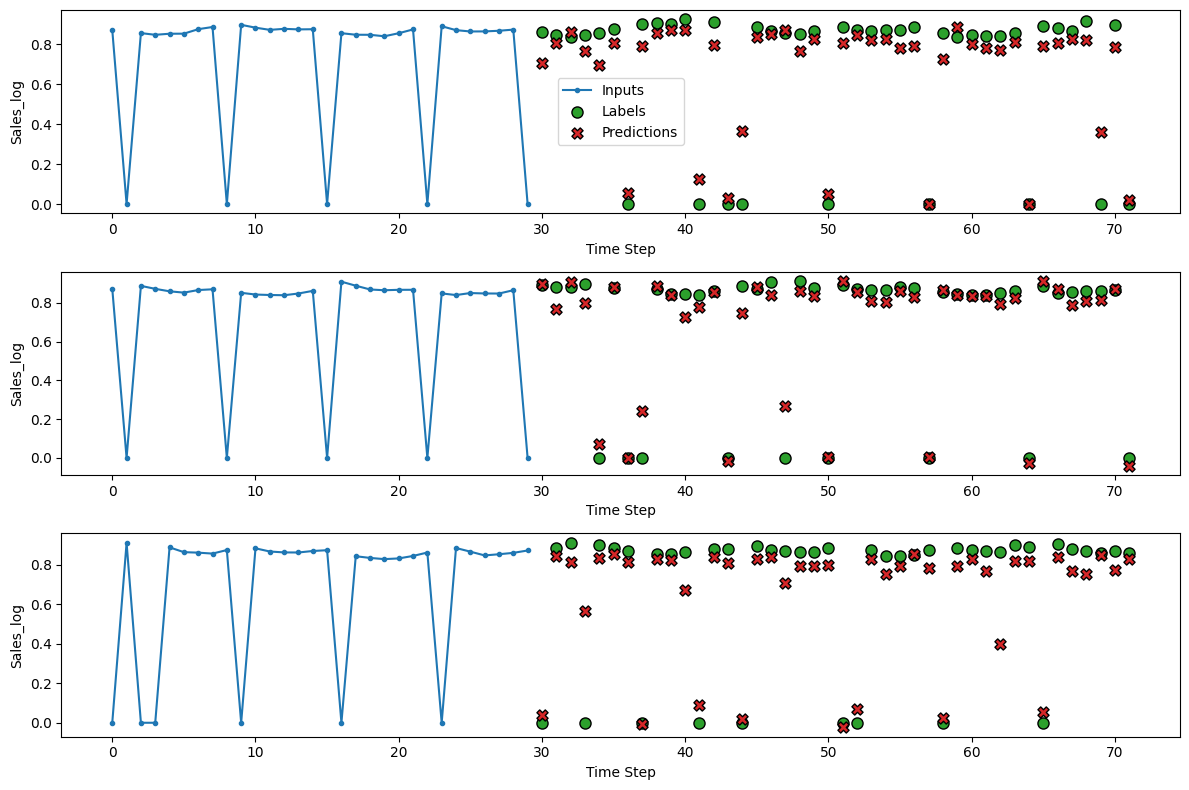

In [45]:
rossman_window.plot(model=structural_model, plot_col='Sales_log')

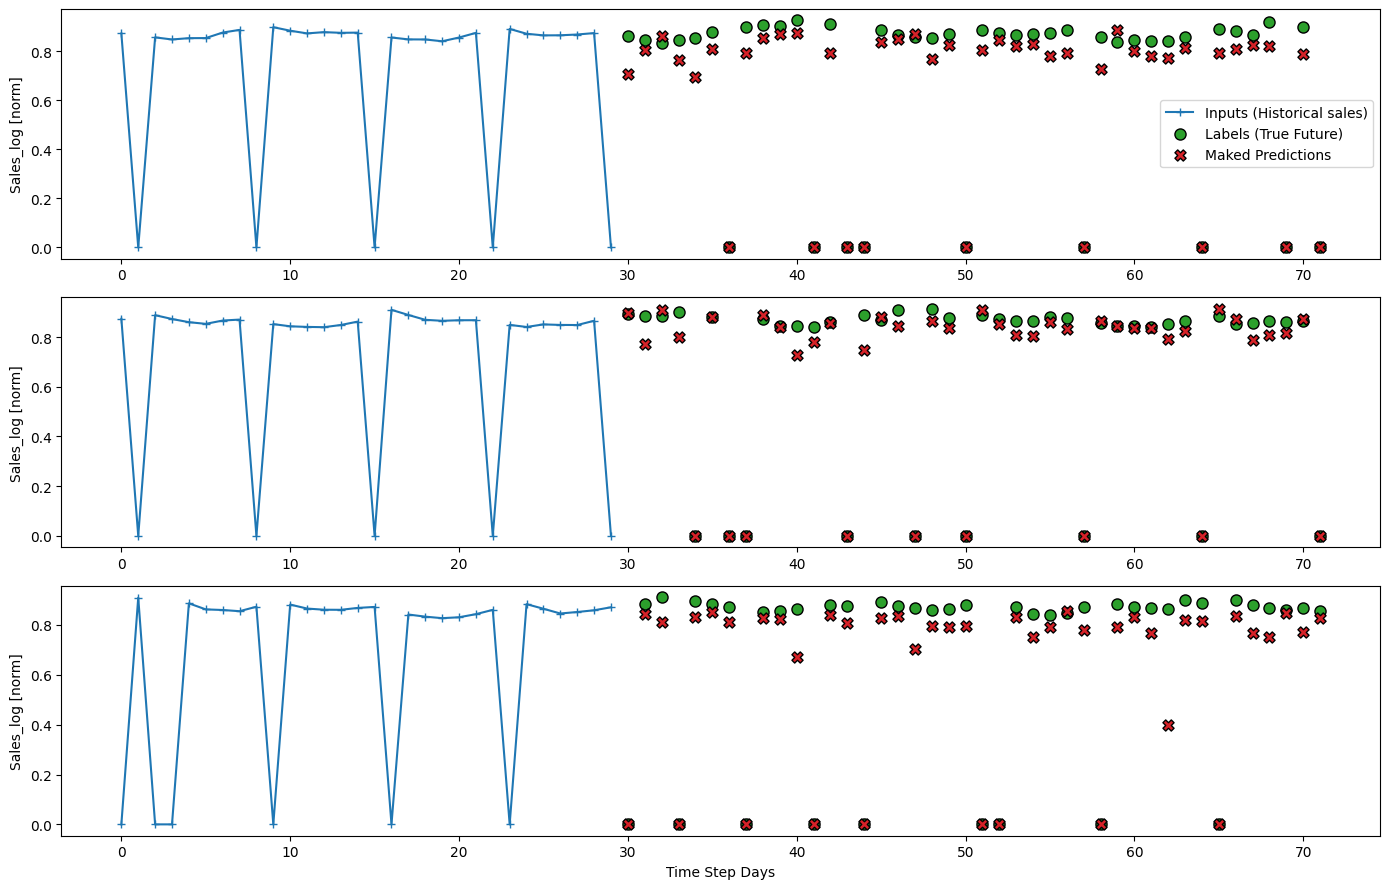

In [46]:
def plot_production_forecast(window_generator, model, plot_col='Sales_log', max_subplots=3):
    inputs, labels  = window_generator.sample_batch 
    raw_predictions = model(inputs).numpy()
    plot_col_index = window_generator.column_indices[plot_col]
    label_col_index = window_generator.label_columns_indices.get(plot_col, None)
    open_idx = window_generator.column_indices.get('Open', None)
    plt.figure(figsize=(14, 9))
    for n in range(min(max_subplots, len(inputs))):
        plt.subplot(max_subplots, 1, n+ 1)
        plt.ylabel(f'{plot_col} [norm]')
        plt.plot(range(0, window_generator.input_width), inputs[n, :, plot_col_index], label='Inputs (Historical sales)', marker='+', zorder=-10)
        if label_col_index is not None:
            plt.scatter(range(window_generator.input_width, window_generator.total_window_size), labels[n, :, label_col_index], edgecolors='k', label='Labels (True Future)', c='#2ca02c', s=64)
            final_predictions= raw_predictions[n, :, 0].copy()
        if label_col_index is not None:
            for step in range(window_generator.label_width):
                if labels[n, step, label_col_index] == 0.0:
                    final_predictions[step] = 0.0
            plt.scatter(range(window_generator.input_width, window_generator.total_window_size), final_predictions,marker='X', edgecolors='k', label="Maked Predictions", c='#d62228', s=64)
        if n== 0:
            plt.legend()
    plt.xlabel('Time Step Days')
    plt.tight_layout()
    plt.show()
plot_production_forecast(rossman_window, structural_model)

In [47]:
def calculate_rmspe(y_true, y_pred):
    mask = y_true != 0 
    y_true_masked = y_true[mask]
    y_pred_masked = y_pred[mask]
    percentage_error = (y_true_masked - y_pred_masked) / y_true_masked 
    rmspe = np.sqrt(np.mean(np.square(percentage_error)))
    return rmspe 

def evaluate_production_performance(window_generator, model):
    all_true_sales = []
    all_pred_sales = []
    label_col_index = window_generator.label_columns_indices['Sales_log']
    for inputs, labels in window_generator.val:
        raw_log_preds = model(inputs).numpy()
        true_log_labels = labels.numpy()
        for b in range(inputs.shape[0]):
            pred_sequence = raw_log_preds[b, :, 0].copy()
            true_sequences =  true_log_labels[b, :, 0].copy()
            for step in range(window_generator.label_width):
                if true_sequences[step] == 0.0:
                    pred_sequence[step] = 0.0 
            true_sale_real = np.expm1(true_sequences)
            pred_sales_real = np.expm1(pred_sequence)
            all_true_sales.extend(true_sale_real)
            all_pred_sales.extend(pred_sales_real)
    all_true_sales = np.array(all_true_sales)
    all_pred_sales = np.array(all_pred_sales)
    mae = np.mean(np.abs(all_true_sales - all_pred_sales))
    rmse = np.sqrt(np.mean(np.square(all_true_sales - all_pred_sales)))
    rmspe = calculate_rmspe(all_true_sales, all_pred_sales)
    print()
    print('final model performance metrics')
    print(f'Mean Absolute Error (MAE): {mae:.2f}')
    print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
    print(f'Official  RMSPE Score: {rmspe:.4f} ({rmspe*100:.2f})')
    print()
    return all_true_sales, all_pred_sales 

true_sales, pred_sales = evaluate_production_performance(rossman_window, structural_model)


final model performance metrics
Mean Absolute Error (MAE): 0.09
Root Mean Squared Error (RMSE): 0.14
Official  RMSPE Score: 0.1196 (11.96)



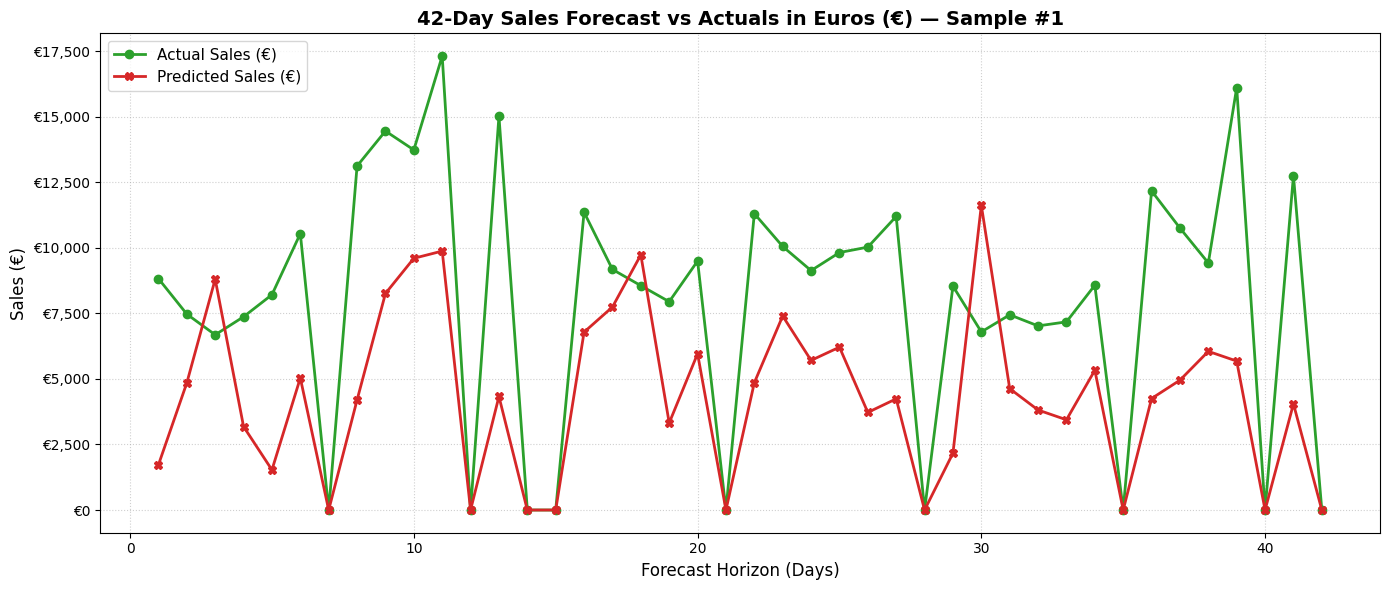

In [57]:
import numpy as np
import matplotlib.pyplot as plt

def plot_42day_euro_forecast(window_generator, model, scaler, train_df, sample_idx=0):
    # 1. Retrieve validation batch and raw predictions
    inputs, labels = window_generator.sample_batch
    raw_preds = model(inputs).numpy()
    
    # 2. Get scaler bounds specifically for 'Sales_log'
    sales_col_idx = list(train_df.columns).index('Sales_log')
    sales_min = scaler.data_min_[sales_col_idx]
    sales_max = scaler.data_max_[sales_col_idx]
    
    # 3. Extract normalized values for selected sample sequence
    true_norm = labels[sample_idx, :, 0].numpy()
    pred_norm = raw_preds[sample_idx, :, 0].copy()
    
    # Zero out predictions on closed store days
    pred_norm[true_norm == 0.0] = 0.0
    
    # 4. Reverse MinMaxScaler FIRST: norm * (max - min) + min
    true_log = true_norm * (sales_max - sales_min) + sales_min
    pred_log = pred_norm * (sales_max - sales_min) + sales_min
    
    # 5. Reverse Log Transformation SECOND: exp(sales_log) - 1
    true_euros = np.where(true_norm == 0, 0, np.expm1(true_log))
    pred_euros = np.where(true_norm == 0, 0, np.expm1(pred_log))
    
    # 6. Plot 42-day forecast horizon
    plt.figure(figsize=(14, 6))
    time_steps = range(1, window_generator.label_width + 1)
    
    plt.plot(time_steps, true_euros, marker='o', linewidth=2, label='Actual Sales (€)', color='#2ca02c')
    plt.plot(time_steps, pred_euros, marker='X', linewidth=2, label='Predicted Sales (€)', color='#d62728')
    
    plt.title(f'42-Day Sales Forecast vs Actuals in Euros (€) — Sample #{sample_idx+1}', fontsize=14, fontweight='bold')
    plt.xlabel('Forecast Horizon (Days)', fontsize=12)
    plt.ylabel('Sales (€)', fontsize=12)
    plt.gca().yaxis.set_major_formatter('€{x:,.0f}')
    
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=11)
    plt.tight_layout()
    plt.show()

# Execute plot on the first sequence
plot_42day_euro_forecast(rossman_window, structural_model, scaler, train_df, sample_idx=0)

In [50]:
import os
import shutil
import joblib
from IPython.display import FileLink

def export_and_download_artifacts(
    model, 
    scaler, 
    window_generator, 
    export_dir='/kaggle/working/export_artifacts', 
    zip_filename='/kaggle/working/rossman_artifacts'
):
    """
    Saves model, scaler, and column metadata into a ZIP file 
    and outputs a clickable HTML download link in Kaggle.
    """
    # 1. Ensure directory exists
    os.makedirs(export_dir, exist_ok=True)
    
    # 2. Save Model, Scaler, and Column indices
    model.save(os.path.join(export_dir, 'rossmann_model.keras'))
    joblib.dump(scaler, os.path.join(export_dir, 'scaler.pkl'))
    joblib.dump(window_generator.column_indices, os.path.join(export_dir, 'column_indices.pkl'))
    
    # 3. Create ZIP Archive
    shutil.make_archive(zip_filename, 'zip', export_dir)
    zip_path = f"{zip_filename}.zip"
    
    print(f"✅ Artifacts successfully bundled into: {zip_path}")
    print("👇 Click the link below to download your ZIP file:\n")
    
    # 4. Generate clickable IPython download link
    return FileLink(os.path.relpath(zip_path))

In [51]:
export_and_download_artifacts(
    model=structural_model,
    scaler=scaler,
    window_generator=rossman_window
)

✅ Artifacts successfully bundled into: /kaggle/working/rossman_artifacts.zip
👇 Click the link below to download your ZIP file:



/kaggle/working/rossman_artifacts.zip